<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/falls/pipeline/01_Entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diseño Experimental: Detección Binaria de Caídas con CNN-LSTM

**Objetivo:** Comparar el rendimiento de un modelo CNN-LSTM de detección binaria (Fall/ADL) entrenado sobre distintos datasets de caídas, utilizando validación cruzada estratificada por sujeto.

### Contrato de Datos de Entrada
Este notebook consume archivos Parquet de la capa `oro/falls/` generados por el pipeline ETL de preprocesamiento. Cada archivo tiene exactamente 7 columnas:

`Subject`, `Activity_Label`, `Activity_Code`, `Trial`, `Sample_Index`, `AVM`, `GVM`

- **AVM / GVM**: Magnitudes vectoriales de aceleración y giroscopio, resampleadas a 100 Hz.
- **Activity_Label**: `Fall` o `ADL` (binario).
- **Activity_Code**: Código original del dataset (sin mapear a taxonomía unificada — ese mapeo se realiza aquí).

### Configuraciones Experimentales
| Config | Datasets | Propósito |
|--------|----------|----------|
| SisFall | SisFall (200→100 Hz) | Baseline individual |
| FallAllD | FallAllD (238→100 Hz) | Baseline individual |
| KFall | KFall (100 Hz nativo) | Baseline individual |
| UPFall | UPFall (100 Hz nativo) | Baseline individual |
| KFall+UPFall | KFall + UPFall | Combinar datasets nativos a 100 Hz |

## 0 · Instalación de dependencias

In [1]:
%pip install numpy pandas scikit-learn pyarrow tensorflow azure-storage-file-datalake matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.6/435.6 kB 28.1 MB/s eta 0:00:00


## 1 · Constantes globales y funciones del pipeline

Parámetros configurables y definición completa de la lógica reutilizable.

In [2]:
import io
import json
import os
import tempfile
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from google.colab import userdata
from azure.storage.filedatalake import DataLakeServiceClient

# --- Constantes configurables --------------------------------------------------
WINDOW_SIZE = 100   # muestras (= 1 segundo a 100 Hz)
WINDOW_STEP = 50    # 50% solapamiento
N_FOLDS = 5
GOLD_SCHEMA_COLS = ["Subject", "Activity_Label", "Activity_Code", "Trial", "Sample_Index", "AVM", "GVM"]
VALID_DATASETS = {"SisFall", "FallAllD", "KFall", "UPFall"}

# Configuraciones experimentales
ALL_EXPERIMENT_CONFIGS = [
    # {"name": "SisFall",       "datasets": ["SisFall"]},
    # {"name": "FallAllD",      "datasets": ["FallAllD"]},
    {"name": "KFall",         "datasets": ["KFall"]},
    {"name": "UPFall",        "datasets": ["UPFall"]},
    {"name": "KFall+UPFall",  "datasets": ["KFall", "UPFall"]},
]

# Configuración a correr en esta sesión: nombre puntual (p. ej. "SisFall") o "TODAS"
CONFIG_TO_RUN = "TODAS"

EXPERIMENT_CONFIGS = (
    ALL_EXPERIMENT_CONFIGS
    if CONFIG_TO_RUN == "TODAS"
    else [c for c in ALL_EXPERIMENT_CONFIGS if c["name"] == CONFIG_TO_RUN]
)
assert EXPERIMENT_CONFIGS, f"CONFIG_TO_RUN '{CONFIG_TO_RUN}' no coincide con ninguna configuración"

print(f"Configuración: WINDOW_SIZE={WINDOW_SIZE}, WINDOW_STEP={WINDOW_STEP}, N_FOLDS={N_FOLDS}")
print(f"Configuraciones experimentales: {[c['name'] for c in EXPERIMENT_CONFIGS]}")

Configuración: WINDOW_SIZE=100, WINDOW_STEP=50, N_FOLDS=5
Configuraciones experimentales: ['KFall', 'UPFall', 'KFall+UPFall']


## 2 · Funciones de carga y persistencia en Azure Data Lake

In [3]:
def _get_file_client(service_client, container_name, directory_name, filename):
    """Retorna un cliente de archivo de Azure Data Lake."""
    return service_client.get_file_system_client(container_name) \
                         .get_directory_client(directory_name) \
                         .get_file_client(filename)

def load_gold(service_client, dataset_names, container_name="oro", directory_name="falls"):
    """Carga y concatena los datasets indicados desde la capa gold (formato parquet).
    Agrega la columna 'Dataset' a cada conjunto."""
    dfs = []
    for name in dataset_names:
        if name not in VALID_DATASETS:
            continue
        filename = f"{name}.parquet"
        file_client = _get_file_client(service_client, container_name, directory_name, filename)
        content = file_client.download_file().readall()
        df = pd.read_parquet(io.BytesIO(content))
        df["Dataset"] = name
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

def _to_native(obj):
    """Convierte tipos de NumPy o recursivos a tipos nativos de Python para JSON."""
    if isinstance(obj, dict):
        return {k: _to_native(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple, set, np.ndarray)):
        return [_to_native(i) for i in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    else:
        return obj

def save_metrics_json(service_client, metrics_dict, config_name, fold_idx, container_name="modelos", directory_name="falls/metricas"):
    """Sube las métricas serializadas como JSON a Azure Data Lake."""
    filename = f"{config_name}_fold{fold_idx}.json"
    file_client = _get_file_client(service_client, container_name, directory_name, filename)
    json_bytes = json.dumps(_to_native(metrics_dict), indent=4).encode("utf-8")
    file_client.upload_data(json_bytes, overwrite=True)
    return len(json_bytes)

def save_model_keras(service_client, model, config_name, container_name="modelos", directory_name="falls"):
    """Sube el modelo entrenado en formato .keras a Azure Data Lake."""
    filename = f"{config_name}_final.keras"
    file_client = _get_file_client(service_client, container_name, directory_name, filename)
    with tempfile.TemporaryDirectory() as tmp_dir:
        model_path = os.path.join(tmp_dir, "model.keras")
        model.save(model_path)
        with open(model_path, "rb") as f:
            model_bytes = f.read()
    file_client.upload_data(model_bytes, overwrite=True)
    return len(model_bytes)

def save_comparison_csv(service_client, results_df, container_name="modelos", directory_name="falls/metricas"):
    """Guarda el DataFrame de resultados resumidos en un CSV en Azure."""
    filename = "tabla_comparativa.csv"
    file_client = _get_file_client(service_client, container_name, directory_name, filename)
    csv_bytes = results_df.to_csv(index=False).encode("utf-8")
    file_client.upload_data(csv_bytes, overwrite=True)
    return len(csv_bytes)

def load_all_metrics(service_client, config_names, n_folds=N_FOLDS, container_name="modelos", directory_name="falls/metricas"):
    """Reconstruye las variables de resultados a partir de los JSON de métricas ya guardados en Azure.
    Devuelve (all_results, config_confusion_totals, all_confusion_dfs) con el mismo formato
    que produce la celda de entrenamiento (celda 21)."""
    all_results = []
    config_confusion_totals = {}
    all_confusion_dfs = []
    for config_name in config_names:
        fold_metrics = []
        total_counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}
        for fold_idx in range(n_folds):
            filename = f"{config_name}_fold{fold_idx}.json"
            file_client = _get_file_client(service_client, container_name, directory_name, filename)
            content = file_client.download_file().readall()
            metrics = json.loads(content.decode("utf-8"))
            fold_metrics.append(metrics)
            for k in ("tp", "fp", "fn", "tn"):
                total_counts[k] += metrics.get(k, 0)
            cm_df = pd.DataFrame(metrics.get("confusion_by_type", []))
            cm_df["config"] = config_name
            all_confusion_dfs.append(cm_df)
        config_confusion_totals[config_name] = total_counts
        metrics_df = pd.DataFrame(fold_metrics)
        summary = {
            "config": config_name,
            "sensitivity_mean": metrics_df["sensitivity"].mean(),
            "sensitivity_std": metrics_df["sensitivity"].std(),
            "specificity_mean": metrics_df["specificity"].mean(),
            "specificity_std": metrics_df["specificity"].std(),
            "precision_mean": metrics_df["precision"].mean(),
            "precision_std": metrics_df["precision"].std(),
            "f1_mean": metrics_df["f1"].mean(),
            "f1_std": metrics_df["f1"].std(),
            "latency_ms_mean": metrics_df["latency_ms"].mean(),
            "model_size_kb": metrics_df["model_size_bytes"].mean() / 1024,
        }
        all_results.append(summary)
    return all_results, config_confusion_totals, all_confusion_dfs

print("✓ Funciones de IO en Azure definidas.")

✓ Funciones de IO en Azure definidas.


## 3 · Mapeo a la taxonomía unificada de tipos de caída

Diccionario `(Dataset, Activity_Code) → grupo_unificado` basado en la taxonomía de 10 grupos (U1–U10). Se genera la columna `Fall_Type_Unified` para la evaluación desglosada.

**Nota:** Los códigos de FallAllD son numéricos (basados en la documentación del dataset) y deben validarse contra los valores reales del parquet antes de usar.

In [4]:
def build_taxonomy_map():
    """Construye y devuelve un diccionario que mapea (Dataset, Activity_Code)
    a la clase unificada de tipo de caída."""
    mapping = {}
    # SisFall
    sisfall_groups = {
        "U1": ["F01", "F02", "F03"],
        "U2": ["F04"],
        "U3": ["F05"],
        "U4": ["F06", "F07"],
        "U5": ["F10", "F11", "F12"],
        "U6": ["F08", "F09"],
        "U7": ["F13", "F14", "F15"]
    }
    for u_code, f_codes in sisfall_groups.items():
        for f in f_codes:
            mapping[("SisFall", f)] = u_code
    # KFall
    kfall_groups = {
        "U1": ["T32", "T33", "T34"],
        "U2": ["T30"],
        "U3": ["T31"],
        "U4": ["T28", "T29"],
        "U5": ["T20", "T21", "T22"],
        "U6": ["T23", "T24"],
        "U7": ["T25", "T26", "T27"]
    }
    for u_code, f_codes in kfall_groups.items():
        for f in f_codes:
            mapping[("KFall", f)] = u_code
    # FallAllD
    fallalld_groups = {
        "U1": ["A103", "A104", "A105", "A106", "A107", "A108", "A109", "A110"],
        "U2": ["A101", "A102"],
        "U3": ["A121", "A122", "A123", "A124", "A125", "A126"],
        "U4": ["A111", "A112", "A113", "A114", "A132", "A133", "A134", "A135"],
        "U5": ["A115", "A116", "A117", "A118", "A119", "A120"],
        "U7": ["A129", "A130", "A131"],
        "U8": ["A127", "A128"]
    }
    for u_code, f_codes in fallalld_groups.items():
        for f in f_codes:
            mapping[("FallAllD", f)] = u_code
    # UPFall
    upfall_groups = {
        "U5": ["5"],
        "U9": ["3", "4"],
        "U10": ["1", "2"]
    }
    for u_code, f_codes in upfall_groups.items():
        for f in f_codes:
            mapping[("UPFall", f)] = u_code
    return mapping

def map_to_unified_taxonomy(df):
    """Añade la columna 'Fall_Type_Unified' usando el mapeo de taxonomía.
    Asigna 'ADL' para actividades normales y 'UNMAPPED' si el código de caída no está."""
    taxonomy = build_taxonomy_map()
    df_mapped = df.copy()
    datasets = df_mapped["Dataset"].values
    act_codes = df_mapped["Activity_Code"].astype(str).values
    act_labels = df_mapped["Activity_Label"].values
    unified_types = [
        "ADL" if label == "ADL" else taxonomy.get((ds, code), "UNMAPPED")
        for ds, code, label in zip(datasets, act_codes, act_labels)
    ]
    df_mapped["Fall_Type_Unified"] = unified_types
    return df_mapped

def build_group_id(df):
    """Crea un identificador único por sujeto agrupando Dataset y Subject."""
    df_grouped = df.copy()
    df_grouped["Group_ID"] = df_grouped["Dataset"] + "_" + df_grouped["Subject"].astype(str)
    return df_grouped

print("✓ Funciones de taxonomía y agrupación definidas.")

✓ Funciones de taxonomía y agrupación definidas.


## 4 · Ventaneo y balanceo de clases

In [5]:
def create_windows(df, window_size=WINDOW_SIZE, window_step=WINDOW_STEP):
    """Genera ventanas deslizantes para los datos.
    Agrupa por Dataset, Subject, Activity_Code, y Trial para no mezclar ensayos."""
    X_list = []
    y_list = []
    meta_list = []
    for keys, group in df.groupby(["Dataset", "Subject", "Activity_Code", "Trial"]):
        group = group.sort_values("Sample_Index")
        n_samples = len(group)
        if n_samples < window_size:
            continue
        avm = group["AVM"].values
        gvm = group["GVM"].values
        data = np.stack([avm, gvm], axis=-1)
        label_val = group["Activity_Label"].iloc[0]
        binary_label = 1 if label_val == "Fall" else 0
        fall_type = group["Fall_Type_Unified"].iloc[0] if "Fall_Type_Unified" in group.columns else None
        for i in range(0, n_samples - window_size + 1, window_step):
            window = data[i:i + window_size]
            X_list.append(window)
            y_list.append(binary_label)
            meta_list.append({
                "Subject": keys[1],
                "Dataset": keys[0],
                "Activity_Code": keys[2],
                "Fall_Type_Unified": fall_type
            })
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    meta = pd.DataFrame(meta_list)
    return X, y, meta

def undersample_train(X, y, meta, random_state=42):
    """Realiza submuestreo aleatorio de la clase mayoritaria (ADL=0)
    para que su cantidad sea igual a la de caídas (Fall=1)."""
    np.random.seed(random_state)
    idx_fall = np.where(y == 1)[0]
    idx_adl = np.where(y == 0)[0]
    if len(idx_adl) > len(idx_fall):
        idx_adl = np.random.choice(idx_adl, size=len(idx_fall), replace=False)
    idx_balanced = np.concatenate([idx_fall, idx_adl])
    np.random.shuffle(idx_balanced)
    return X[idx_balanced], y[idx_balanced], meta.iloc[idx_balanced].reset_index(drop=True)

print("✓ Funciones de ventaneo y balanceo definidas.")

✓ Funciones de ventaneo y balanceo definidas.


## 5 · Métricas de evaluación

In [6]:
def compute_binary_metrics(y_true, y_pred):
    """Calcula métricas binarias estándar. (Caída=1, ADL=0)"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 0.0
    if precision + sensitivity > 0:
        f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    return {
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "f1": float(f1),
        "tp": int(tp), "fn": int(fn), "tn": int(tn), "fp": int(fp)
    }

def confusion_by_fall_type(y_true, y_pred, fall_types):
    """Desglosa los aciertos y fallos por tipo de caída unificado."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    fall_types = np.asarray(fall_types)
    unique_types = np.unique(fall_types)
    rows = []
    for ftype in unique_types:
        idx = np.where(fall_types == ftype)[0]
        n_total = len(idx)
        n_pred_fall = int(np.sum(y_pred[idx] == 1))
        n_pred_adl = int(np.sum(y_pred[idx] == 0))
        if ftype == "ADL":
            det_rate = n_pred_adl / n_total if n_total > 0 else 0.0
        else:
            det_rate = n_pred_fall / n_total if n_total > 0 else 0.0
        rows.append({
            "Fall_Type_Unified": ftype,
            "n_total": n_total,
            "n_pred_fall": n_pred_fall,
            "n_pred_adl": n_pred_adl,
            "detection_rate": float(det_rate)
        })
    return pd.DataFrame(rows)

print("✓ Funciones de métricas definidas.")

✓ Funciones de métricas definidas.


## 6 · Arquitectura CNN-LSTM, entrenamiento y funciones de visualización

In [7]:
def build_cnn_lstm(window_size=WINDOW_SIZE, n_channels=2):
    """Construye y compila el modelo CNN-LSTM de TensorFlow/Keras."""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(window_size, n_channels)),
        tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_model(dataset_names, fold_idx, X_train, y_train, X_val, y_val, window_size=WINDOW_SIZE, n_channels=2, epochs=50, batch_size=32, return_history=False):
    """Entrena el modelo de detección de caídas. Opcionalmente retorna el historial de entrenamiento."""
    model = build_cnn_lstm(window_size=window_size, n_channels=n_channels)
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    config_name = "_".join(dataset_names)
    print(f"Training config: {config_name} - Fold: {fold_idx}")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )
    if return_history:
        return model, history.history
    return model

def measure_latency(model, input_shape, n_runs=100):
    """Mide el tiempo de inferencia promedio en milisegundos."""
    dummy_input = np.random.randn(1, *input_shape).astype(np.float32)
    for _ in range(5):
        model.predict(dummy_input, verbose=0)
    start = time.perf_counter()
    for _ in range(n_runs):
        model.predict(dummy_input, verbose=0)
    end = time.perf_counter()
    latency_ms = ((end - start) / n_runs) * 1000
    return float(latency_ms)

def measure_model_size(model):
    """Mide el tamaño del modelo serializado en bytes."""
    with tempfile.TemporaryDirectory() as tmp_dir:
        model_path = os.path.join(tmp_dir, "temp.keras")
        model.save(model_path)
        return os.path.getsize(model_path)

# --- Funciones de Visualización ------------------------------------------------
def plot_confusion_matrices(metrics_dict_by_config):
    """Dibuja matrices de confusión 2x2 para cada configuración experimental,
    con conteos acumulados de los K folds y porcentajes normalizados por fila."""
    n_configs = len(metrics_dict_by_config)
    fig, axes = plt.subplots(1, n_configs, figsize=(4.2 * n_configs, 4.6), squeeze=False)
    all_cm = [np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]]) for m in metrics_dict_by_config.values()]
    vmax = max(cm.max() for cm in all_cm)
    for idx, (config_name, m) in enumerate(metrics_dict_by_config.items()):
        ax = axes[0, idx]
        cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
        im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)
        row_totals = cm.sum(axis=1, keepdims=True)
        pct = cm / np.where(row_totals == 0, 1, row_totals)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}\n({pct[i, j]:.0%})", ha="center", va="center",
                        color="black" if cm[i, j] < vmax / 2 else "white", fontsize=9)
        sens = m["tp"] / (m["tp"] + m["fn"]) if (m["tp"] + m["fn"]) > 0 else 0.0
        spec = m["tn"] / (m["tn"] + m["fp"]) if (m["tn"] + m["fp"]) > 0 else 0.0
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["ADL (0)", "Fall (1)"])
        ax.set_yticklabels(["ADL (0)", "Fall (1)"])
        ax.set_title(f"{config_name}\nSens: {sens:.1%} · Spec: {spec:.1%}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicción")
        if idx == 0:
            ax.set_ylabel("Valor Real")
    fig.suptitle("Matrices de Confusión Agregadas (conteos acumulados de los K folds)", fontsize=13, fontweight="bold")
    fig.colorbar(im, ax=axes[0], fraction=0.02, pad=0.04)
    fig.subplots_adjust(left=0.05, right=0.93, top=0.82, bottom=0.16, wspace=0.35)
    return fig

def plot_learning_curves_grid(history_dict_by_config):
    """Dibuja curvas de aprendizaje (Loss y Accuracy vs Épocas) para cada configuración
    en un par de ejes dedicado, con el nombre de la configuración en el título."""
    config_names = list(history_dict_by_config.keys())
    n = len(config_names)
    n_cols = 3
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(6 * n_cols, 3.4 * n_rows), squeeze=False)
    for idx, config_name in enumerate(config_names):
        history_dict = history_dict_by_config[config_name]
        ax1 = axes[idx // n_cols, (idx % n_cols) * 2]
        ax2 = axes[idx // n_cols, (idx % n_cols) * 2 + 1]
        epochs = range(1, len(history_dict.get("loss", [])) + 1)
        ax1.plot(epochs, history_dict.get("loss", []), label="Train Loss", marker="o", markersize=3, color="#d95f02")
        ax1.plot(epochs, history_dict.get("val_loss", []), label="Val Loss", marker="s", markersize=3, color="#7570b3")
        ax1.set_title(f"{config_name} — Pérdida (Fold 0)", fontsize=10, fontweight="bold")
        ax1.set_xlabel("Época")
        ax1.set_ylabel("Pérdida")
        ax1.legend()
        ax1.grid(True, linestyle="--", alpha=0.6)
        ax2.plot(epochs, history_dict.get("accuracy", []), label="Train Accuracy", marker="o", markersize=3, color="#1b9e77")
        ax2.plot(epochs, history_dict.get("val_accuracy", []), label="Val Accuracy", marker="s", markersize=3, color="#e7298a")
        ax2.set_title(f"{config_name} — Precisión (Fold 0)", fontsize=10, fontweight="bold")
        ax2.set_xlabel("Época")
        ax2.set_ylabel("Precisión")
        ax2.legend()
        ax2.grid(True, linestyle="--", alpha=0.6)
    for j in range(n * 2, n_rows * n_cols * 2):
        axes[j // (n_cols * 2), j % (n_cols * 2)].axis("off")
    fig.suptitle("Curvas de Aprendizaje por Configuración (Fold 0, con early stopping)", fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def plot_detection_by_fall_type_and_config(confusion_df):
    """Heatmap: tasa de detección por tipo de caída (filas) y configuración (columnas)."""
    pivot = confusion_df.pivot(index="Fall_Type_Unified", columns="config", values="detection_rate")
    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1] * 1.6), max(4, pivot.shape[0] * 0.5)))
    im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Configuración")
    ax.set_ylabel("Tipo de Caída / Actividad")
    ax.set_title("Tasa de Detección por Tipo de Caída y Configuración", fontsize=12, fontweight="bold")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Tasa de Detección")
    plt.tight_layout()
    return fig

def plot_f1_bars(results_df):
    """Barras horizontales de F1-Score (media ± SD entre folds) por configuración."""
    df_sorted = results_df.sort_values("f1_mean", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.barh(df_sorted["config"], df_sorted["f1_mean"], xerr=df_sorted["f1_std"],
                   capsize=4, color="#2b5c8f", edgecolor="black", linewidth=0.8)
    ax.set_xlim(0, 1)
    ax.set_title("F1-Score por Configuración (media ± SD entre folds)", fontsize=12, fontweight="bold")
    ax.set_xlabel("F1-Score")
    ax.set_ylabel("Configuración")
    ax.grid(axis="x", linestyle="--", alpha=0.6)
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.1%}", ha="left", va="center", fontsize=9)
    plt.tight_layout()
    return fig

print("✓ Arquitectura CNN-LSTM y funciones de visualización definidas.")
build_cnn_lstm().summary()

✓ Arquitectura CNN-LSTM y funciones de visualización definidas.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,025 (347.75 KB)

 Trainable params: 89,025 (347.75 KB)

 Non-trainable params: 0 (0.00 B)

## 7 · Conexión a Azure Data Lake

Se establece la conexión con el Data Lake utilizando las credenciales seguras del entorno de Colab.

In [8]:
CONNECTION_STRING = userdata.get("cadenaAzure")
service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
print("✓ Conexión a Azure Data Lake establecida.")

✓ Conexión a Azure Data Lake establecida.


## 8 · Inspección de Activity_Code por dataset

Antes de aplicar el mapeo de taxonomía, se inspeccionan los valores reales de `Activity_Code` en cada parquet para validar que el diccionario de mapeo es correcto.

In [9]:
taxonomy = build_taxonomy_map()

for ds_name in VALID_DATASETS:
    try:
        df_tmp = load_gold(service_client, [ds_name])
        falls_only = df_tmp[df_tmp["Activity_Label"] == "Fall"]
        codes = sorted(falls_only["Activity_Code"].astype(str).unique())
        print(f"[{ds_name}] {len(codes)} códigos de caída: {codes}")
        uncovered = [c for c in codes if (ds_name, c) not in taxonomy]
        if uncovered:
            print(f"⚠️  {ds_name}: códigos de caída sin cobertura en taxonomy: {uncovered}")
        else:
            print(f"✓  {ds_name}: todos los códigos de caída cubiertos por taxonomy")
        adl_only = df_tmp[df_tmp["Activity_Label"] == "ADL"]
        adl_codes = sorted(adl_only["Activity_Code"].astype(str).unique())
        ellipsis = "..." if len(adl_codes) > 10 else ""
        print(f"  ADL: {len(adl_codes)} códigos: {adl_codes[:10]}{ellipsis}")
        del df_tmp
        gc.collect()
    except Exception as e:
        print(f"[{ds_name}] Error al cargar: {e}")

print(f"\nTotal de entradas en el diccionario de taxonomía: {len(taxonomy)}")

[FallAllD] 35 códigos de caída: ['A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A118', 'A119', 'A120', 'A121', 'A122', 'A123', 'A124', 'A125', 'A126', 'A127', 'A128', 'A129', 'A130', 'A131', 'A132', 'A133', 'A134', 'A135']
✓  FallAllD: todos los códigos de caída cubiertos por taxonomy
  ADL: 32 códigos: ['A013', 'A014', 'A015', 'A016', 'A017', 'A018', 'A019', 'A020', 'A021', 'A022']...
[KFall] 15 códigos de caída: ['T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27', 'T28', 'T29', 'T30', 'T31', 'T32', 'T33', 'T34']
✓  KFall: todos los códigos de caída cubiertos por taxonomy
  ADL: 21 códigos: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10']...
[UPFall] 5 códigos de caída: ['1', '2', '3', '4', '5']
✓  UPFall: todos los códigos de caída cubiertos por taxonomy
  ADL: 6 códigos: ['10', '11', '6', '7', '8', '9']
[SisFall] 15 códigos de caída: ['F01', 'F02', 'F03', 'F04', 'F05',

## 9 · Orquestación de experimentos con validación cruzada

Para cada configuración experimental, se ejecuta el pipeline completo:
1. Carga de datos → mapeo de taxonomía → generación de `Group_ID`
2. `StratifiedGroupKFold` (K=5) sobre `Group_ID`, estratificando por `Activity_Label`
3. Validación anidada: `GroupShuffleSplit` (90/10) dentro de cada fold de train
4. Ventaneo → balanceo (solo train) → entrenamiento → evaluación
5. Métricas agregadas como media ± desvío estándar entre folds

In [10]:
all_results = []
config_confusion_totals = {}
all_confusion_dfs = []
last_histories = {}

for config in EXPERIMENT_CONFIGS:
    config_name = config["name"]
    dataset_names = config["datasets"]
    print(f"\n{"="*70}")
    print(f"CONFIGURACIÓN: {config_name} — Datasets: {dataset_names}")
    print("="*70)

    df = load_gold(service_client, dataset_names)
    df = map_to_unified_taxonomy(df)
    df = build_group_id(df)

    unmapped = df[(df["Activity_Label"] == "Fall") & (df["Fall_Type_Unified"] == "UNMAPPED")]
    if len(unmapped) > 0:
        unmapped_codes = unmapped[["Dataset", "Activity_Code"]].drop_duplicates()
        print(f"⚠️ {len(unmapped_codes)} códigos de caída sin mapear:")
        print(unmapped_codes.to_string(index=False))

    y_binary = (df["Activity_Label"] == "Fall").astype(int).values
    groups = df["Group_ID"].values
    n_groups = len(np.unique(groups))
    n_fall = int(y_binary.sum())
    n_adl = len(y_binary) - n_fall
    print(f"Filas: {len(df):,} | Grupos (sujetos): {n_groups} | Fall: {n_fall:,} | ADL: {n_adl:,}")

    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_metrics = []
    fold_confusion_dfs = []
    total_counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}

    for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(np.zeros(len(df)), y_binary, groups)):
        print(f"\n--- Fold {fold_idx} ---")
        train_df = df.iloc[train_idx]
        test_df = df.iloc[test_idx]

        gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=fold_idx)
        inner_train_idx, val_idx = next(gss.split(
            np.zeros(len(train_df)),
            (train_df["Activity_Label"] == "Fall").astype(int).values,
            train_df["Group_ID"].values
        ))
        train_inner_df = train_df.iloc[inner_train_idx]
        val_df = train_df.iloc[val_idx]

        X_train, y_train, meta_train = create_windows(train_inner_df)
        X_val, y_val, meta_val = create_windows(val_df)
        X_test, y_test, meta_test = create_windows(test_df)

        X_train_bal, y_train_bal, meta_train_bal = undersample_train(X_train, y_train, meta_train, random_state=fold_idx)

        # Guardar historial del Fold 0 para visualización de curva de aprendizaje
        if fold_idx == 0:
            model, history_dict = train_model(dataset_names, fold_idx, X_train_bal, y_train_bal, X_val, y_val, return_history=True)
            last_histories[config_name] = history_dict
        else:
            model = train_model(dataset_names, fold_idx, X_train_bal, y_train_bal, X_val, y_val)

        y_pred_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_pred_prob >= 0.5).astype(int)

        metrics = compute_binary_metrics(y_test, y_pred)
        total_counts["tp"] += metrics["tp"]
        total_counts["fp"] += metrics["fp"]
        total_counts["fn"] += metrics["fn"]
        total_counts["tn"] += metrics["tn"]

        cm_df = confusion_by_fall_type(y_test, y_pred, meta_test["Fall_Type_Unified"].values)
        cm_df["config"] = config_name
        fold_confusion_dfs.append(cm_df)
        all_confusion_dfs.append(cm_df)

        lat_ms = measure_latency(model, input_shape=(WINDOW_SIZE, 2), n_runs=50)
        size_bytes = measure_model_size(model)
        metrics["latency_ms"] = lat_ms
        metrics["model_size_bytes"] = size_bytes
        fold_metrics.append(metrics)

        fold_result = {**metrics, "confusion_by_type": cm_df.to_dict(orient="records")}
        save_metrics_json(service_client, fold_result, config_name, fold_idx)

        del model, X_train, y_train, X_val, y_val, X_test, y_test, X_train_bal, y_train_bal
        gc.collect()
        tf.keras.backend.clear_session()

    config_confusion_totals[config_name] = total_counts
    metrics_df = pd.DataFrame(fold_metrics)
    summary = {
        "config": config_name,
        "sensitivity_mean": metrics_df["sensitivity"].mean(),
        "sensitivity_std": metrics_df["sensitivity"].std(),
        "specificity_mean": metrics_df["specificity"].mean(),
        "specificity_std": metrics_df["specificity"].std(),
        "precision_mean": metrics_df["precision"].mean(),
        "precision_std": metrics_df["precision"].std(),
        "f1_mean": metrics_df["f1"].mean(),
        "f1_std": metrics_df["f1"].std(),
        "latency_ms_mean": metrics_df["latency_ms"].mean(),
        "model_size_kb": metrics_df["model_size_bytes"].mean() / 1024,
    }
    all_results.append(summary)
    del df
    gc.collect()

print("\n✅ Todos los experimentos completados.")


CONFIGURACIÓN: KFall — Datasets: ['KFall']
Filas: 3,995,100 | Grupos (sujetos): 32 | Fall: 1,725,407 | ADL: 2,269,693

--- Fold 0 ---
Training config: KFall - Fold: 0

--- Fold 1 ---
Training config: KFall - Fold: 1

--- Fold 2 ---
Training config: KFall - Fold: 2

--- Fold 3 ---
Training config: KFall - Fold: 3

--- Fold 4 ---
Training config: KFall - Fold: 4

CONFIGURACIÓN: UPFall — Datasets: ['UPFall']
Filas: 294,678 | Grupos (sujetos): 17 | Fall: 45,951 | ADL: 248,727

--- Fold 0 ---
Training config: UPFall - Fold: 0

--- Fold 1 ---
Training config: UPFall - Fold: 1

--- Fold 2 ---
Training config: UPFall - Fold: 2

--- Fold 3 ---
Training config: UPFall - Fold: 3

--- Fold 4 ---
Training config: UPFall - Fold: 4

CONFIGURACIÓN: KFall+UPFall — Datasets: ['KFall', 'UPFall']
Filas: 4,289,778 | Grupos (sujetos): 49 | Fall: 1,771,358 | ADL: 2,518,420

--- Fold 0 ---
Training config: KFall_UPFall - Fold: 0

--- Fold 1 ---
Training config: KFall_UPFall - Fold: 1

--- Fold 2 ---
Training

## 10 · Visualizaciones Clave de Evaluación

A continuación se integran visualizaciones clave para interpretar el rendimiento del modelo desde una perspectiva de ingeniería y negocio.

### 10.1 Curvas de Aprendizaje (Pérdida y Precisión)

**¿Qué representa esta gráfica?**
Cada par de paneles muestra la evolución del aprendizaje época a época del **Fold 0** de una configuración experimental, cuyo nombre aparece en el título de cada panel. La curva de **Pérdida (Loss)** indica el margen de error del modelo (valores más bajos son mejores) y la curva de **Precisión (Accuracy)** la proporción de aciertos.

**¿Cómo interpretarla?**
- Si la línea de validación (morado/rosa) desciende de forma pareja junto a la de entrenamiento (naranja/verde), el modelo está aprendiendo patrones reales.
- Si la línea de validación se separa hacia arriba mientras el entrenamiento sigue bajando, indicaría sobreajuste (*overfitting*).
- Las curvas terminan en épocas distintas porque el entrenamiento usa *early stopping* (paciencia de 5 épocas sobre la pérdida de validación).


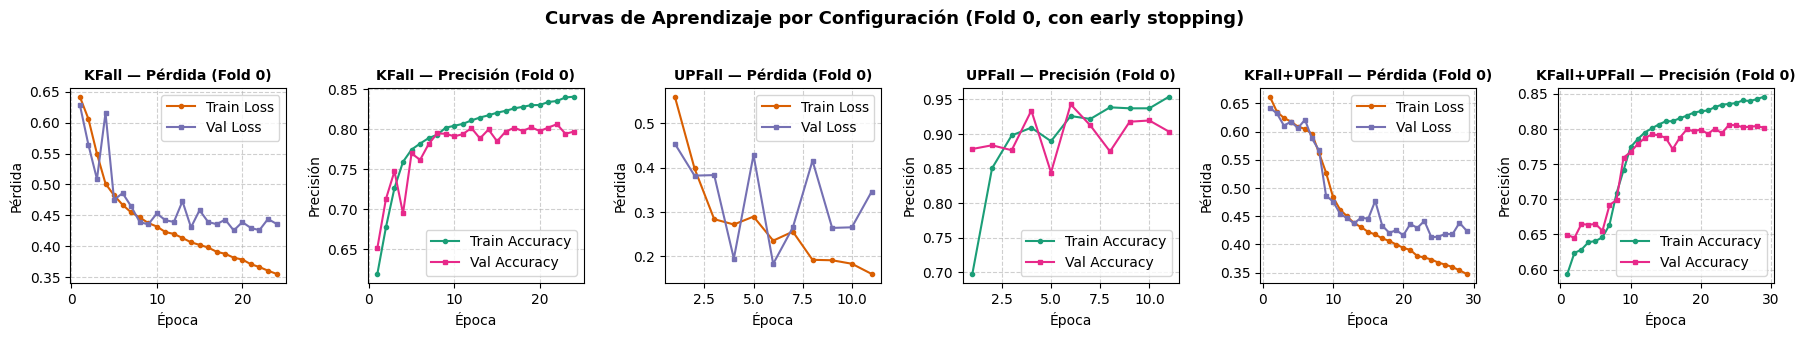

In [11]:
fig1 = plot_learning_curves_grid(last_histories)
plt.show()


### 10.2 Matrices de Confusión por Configuración

**¿Qué representa esta gráfica?**
Cuadros de diagnóstico 2x2 que comparan las predicciones realizadas por el modelo con la realidad física observada para cada dataset. Cada celda muestra el **conteo acumulado de los K folds** y, entre paréntesis, el **porcentaje normalizado por fila** (la fila ADL y la fila Fall suman 100% cada una). El título de cada panel indica la configuración junto con su **Sensibilidad** y **Especificidad** globales:

- **TN (Verdaderos Negativos, arriba-izquierda)**: Movimientos cotidianos identificados correctamente como NO caída.
- **TP (Verdaderos Positivos, abajo-derecha)**: Caídas reales detectadas con éxito por el sensor.
- **FP (Falsos Positivos, arriba-derecha)**: Falsas alarmas (actividad diaria confundida con caída).
- **FN (Falsos Negativos, abajo-izquierda)**: Caídas no detectadas (representan el riesgo principal a minimizar).


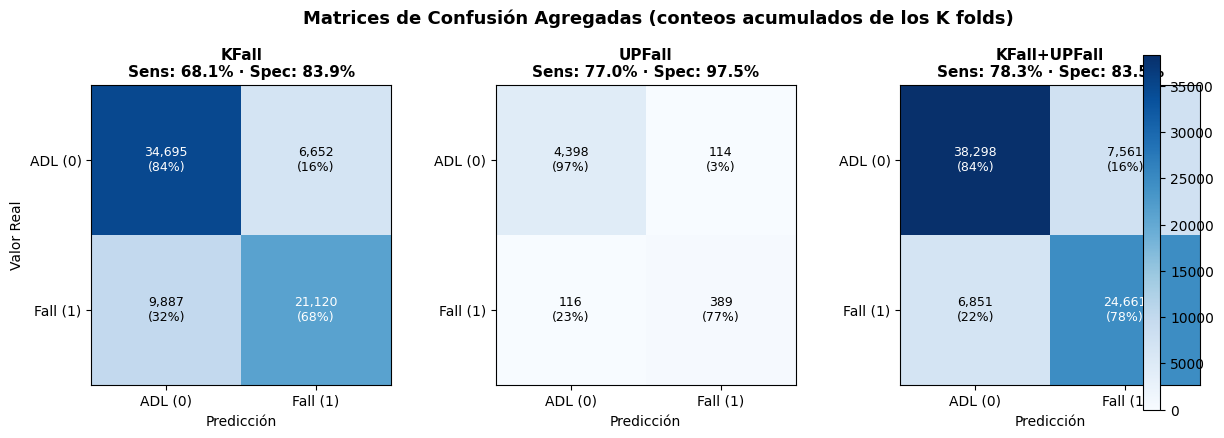

In [12]:
fig2 = plot_confusion_matrices(config_confusion_totals)
plt.show()

### 10.3 Tasa de Detección por Tipo Unificado de Caída (U1–U10)

**¿Qué representa esta gráfica?**
Muestra el porcentaje de acierto del sistema desglosado por cada tipo de movimiento o causa de caída de la taxonomía unificada (ej. resbalones U1, tropezones U2, mareos U4, colapsos desde la silla U5, etc.).

**¿Por qué es importante?**
Permite identificar si el modelo tiene puntos ciegos en ciertos accidentes particulares (ej. caídas lentas vs. caídas súbitas) para reforzar el entrenamiento en versiones futuras.

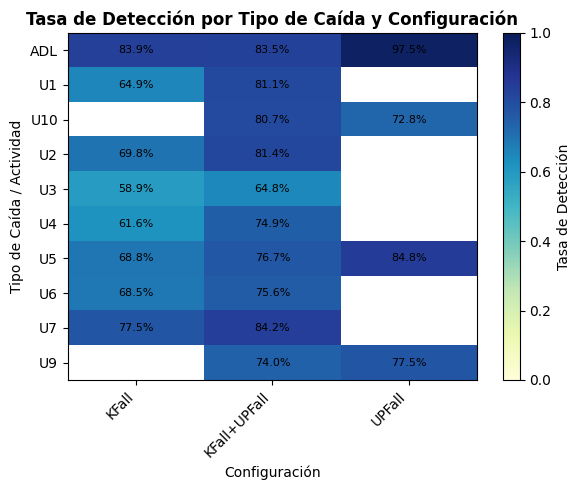

In [13]:
if len(all_confusion_dfs) > 0:
    global_cm_df = pd.concat(all_confusion_dfs, ignore_index=True)
    aggregated_cm = global_cm_df.groupby(['config', 'Fall_Type_Unified']).agg({
        'n_total': 'sum',
        'n_pred_fall': 'sum',
        'n_pred_adl': 'sum'
    }).reset_index()
    aggregated_cm['detection_rate'] = aggregated_cm.apply(
        lambda r: r['n_pred_adl'] / r['n_total'] if r['Fall_Type_Unified'] == 'ADL' else r['n_pred_fall'] / r['n_total'], axis=1
    )
    fig3 = plot_detection_by_fall_type_and_config(aggregated_cm)
    plt.show()

### 10.4 F1-Score por Configuración (media ± SD entre folds)

**¿Qué representa esta gráfica?**
Compara la calidad diagnóstica global de cada configuración mediante el **F1-Score**, la media armónica entre sensibilidad y precisión. Cada barra muestra la media de los K folds y la barra de error la desviación estándar entre ellos.

**¿Cómo interpretarla?**
- Una barra más larga indica mejor equilibrio entre detectar caídas y evitar falsas alarmas.
- Una barra de error corta indica un comportamiento estable entre folds (baja variabilidad según los sujetos de evaluación); una barra larga advierte que el rendimiento depende del conjunto de evaluación.

La latencia y el tamaño del modelo no aparecen en este gráfico porque todas las configuraciones usan la misma arquitectura CNN-LSTM y son prácticamente idénticos (~70 ms, ~1.1 MB); pueden consultarse en la tabla comparativa de la sección 11.


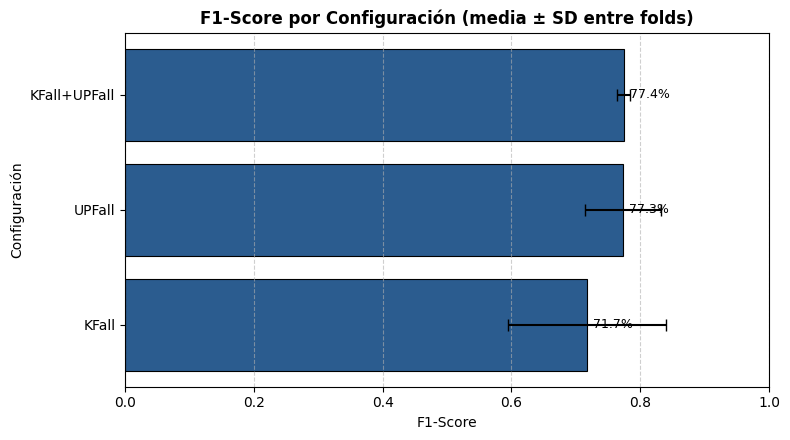

In [14]:
fig4 = plot_f1_bars(pd.DataFrame(all_results))
plt.show()


## 11 · Tabla comparativa de resultados

Resumen con una fila por configuración y métricas agregadas (media ± desvío) entre los K folds.

In [15]:
comparison_df = pd.DataFrame(all_results)
display_df = pd.DataFrame()
display_df["Configuración"] = comparison_df["config"]
display_df["Sensibilidad"] = comparison_df.apply(lambda r: f'{r["sensitivity_mean"]:.4f} ± {r["sensitivity_std"]:.4f}', axis=1)
display_df["Especificidad"] = comparison_df.apply(lambda r: f'{r["specificity_mean"]:.4f} ± {r["specificity_std"]:.4f}', axis=1)
display_df["Precisión"] = comparison_df.apply(lambda r: f'{r["precision_mean"]:.4f} ± {r["precision_std"]:.4f}', axis=1)
display_df["F1-Score"] = comparison_df.apply(lambda r: f'{r["f1_mean"]:.4f} ± {r["f1_std"]:.4f}', axis=1)
display_df["Latencia (ms)"] = comparison_df["latency_ms_mean"].apply(lambda x: f"{x:.2f}")
display_df["Tamaño (KB)"] = comparison_df["model_size_kb"].apply(lambda x: f"{x:.1f}")

print("Tabla Comparativa de Resultados")
print("=" * 120)
print(display_df.to_string(index=False))

save_comparison_csv(service_client, comparison_df)
print("\n✅ Tabla comparativa guardada en modelos/falls/metricas/tabla_comparativa.csv")

Tabla Comparativa de Resultados
Configuración    Sensibilidad   Especificidad       Precisión        F1-Score Latencia (ms) Tamaño (KB)
        KFall 0.6922 ± 0.1615 0.8391 ± 0.0045 0.7545 ± 0.0592 0.7174 ± 0.1228         74.94      1093.6
       UPFall 0.7802 ± 0.1058 0.9738 ± 0.0117 0.7755 ± 0.0610 0.7733 ± 0.0597         80.67      1093.6
 KFall+UPFall 0.7866 ± 0.0425 0.8345 ± 0.0241 0.7646 ± 0.0314 0.7741 ± 0.0099         78.71      1093.6

✅ Tabla comparativa guardada en modelos/falls/metricas/tabla_comparativa.csv


## 12 · Reentrenamiento de modelos finales (sin held-out)

Para cada configuración, se reentrena un único modelo final usando **todos** los datos disponibles (sin partición de evaluación). Estos modelos se guardan en `modelos/falls/{config}_final.keras`.

**Nota:** estos modelos NO se usan para estimar métricas — las métricas reportadas provienen exclusivamente de los K folds del CV. Estos modelos son para uso posterior (ej. conversión a TFLite para deployment en ESP32).

In [16]:
for config in EXPERIMENT_CONFIGS:
    config_name = config["name"]
    dataset_names = config["datasets"]
    print(f"\nReentrenando modelo final para: {config_name}")

    df = load_gold(service_client, dataset_names)
    df = map_to_unified_taxonomy(df)
    df = build_group_id(df)

    X_all, y_all, meta_all = create_windows(df)
    print(f"  Ventanas totales: {len(y_all):,} (Fall: {int((y_all==1).sum()):,}, ADL: {int((y_all==0).sum()):,})")

    X_bal, y_bal, meta_bal = undersample_train(X_all, y_all, meta_all, random_state=0)

    n_val = max(1, int(len(y_bal) * 0.1))
    X_train_final = X_bal[n_val:]
    y_train_final = y_bal[n_val:]
    X_val_final = X_bal[:n_val]
    y_val_final = y_bal[:n_val]

    model_final = train_model(dataset_names, -1, X_train_final, y_train_final, X_val_final, y_val_final)

    size = save_model_keras(service_client, model_final, config_name)
    print(f"  ✅ Modelo guardado: modelos/falls/{config_name}_final.keras ({size / 1024:.1f} KB)")

    del df, X_all, y_all, X_bal, y_bal, model_final
    gc.collect()
    tf.keras.backend.clear_session()

print("\n" + "="*70)
print("  5 modelos finales guardados en modelos/falls/")
print("="*70)


Reentrenando modelo final para: KFall
  Ventanas totales: 72,354 (Fall: 31,007, ADL: 41,347)
Training config: KFall - Fold: -1
  ✅ Modelo guardado: modelos/falls/KFall_final.keras (1093.6 KB)

Reentrenando modelo final para: UPFall
  Ventanas totales: 5,017 (Fall: 505, ADL: 4,512)
Training config: UPFall - Fold: -1
  ✅ Modelo guardado: modelos/falls/UPFall_final.keras (1093.6 KB)

Reentrenando modelo final para: KFall+UPFall
  Ventanas totales: 77,371 (Fall: 31,512, ADL: 45,859)
Training config: KFall_UPFall - Fold: -1
  ✅ Modelo guardado: modelos/falls/KFall+UPFall_final.keras (1093.6 KB)

  5 modelos finales guardados en modelos/falls/


## 13 · Conclusión

Se completó el diseño experimental completo:
- **5 configuraciones** evaluadas con `StratifiedGroupKFold` (K=5) sobre `Group_ID`.
- **Validación anidada** (sin fuga de sujetos entre train/val/test).
- **Balanceo por undersampling** aplicado únicamente sobre ventanas de train.
- **Métricas globales** (Sensibilidad, Especificidad, Precisión, F1) como media ± desvío entre folds.
- **Matriz de confusión** desglosada por `Fall_Type_Unified` (taxonomía de 10 grupos).
- **4 Visualizaciones clave** con descripciones explicativas accesibles para stakeholders no técnicos.
- **Latencia y tamaño del modelo** en float32 (sin cuantización — esa etapa es posterior).
- **5 modelos finales** reentrenados sin held-out, persistidos como `.keras` para conversión futura a TFLite.

## 14 · Sensibilidad vs. Especificidad (benchmarks de referencia)

**¿Qué mide cada eje?**
- **Sensibilidad (eje X):** proporción de caídas reales correctamente detectadas. Una sensibilidad baja implica mayor riesgo de **no detectar caídas reales** (falsos negativos).
- **Especificidad (eje Y):** proporción de actividades normales correctamente clasificadas. Una especificidad baja implica **mayor cantidad de falsas alarmas** (falsos positivos).

Ambas métricas son relevantes para un sistema de detección de caídas: se busca detectar la mayor proporción posible de caídas reales y, al mismo tiempo, minimizar las falsas alarmas. Valores altos en **ambos ejes** representan un mejor comportamiento; el gráfico permite visualizar simultáneamente ese compromiso.

**Líneas y marcas de referencia (benchmarks de viabilidad reportados en la literatura):**
- Línea vertical en **Sensibilidad = 95%** y línea horizontal en **Especificidad = 98%**, con marcas de diamante sobre los propios ejes en los valores exactos.

La zona objetivo queda a la **derecha de la línea vertical** (sensibilidad ≥ 95%) y **por encima de la línea horizontal** (especificidad ≥ 98%); es decir, la **esquina superior derecha** del gráfico.

Las barras de error representan la **variabilidad entre folds (± 1 SD)**, no intervalos de confianza.


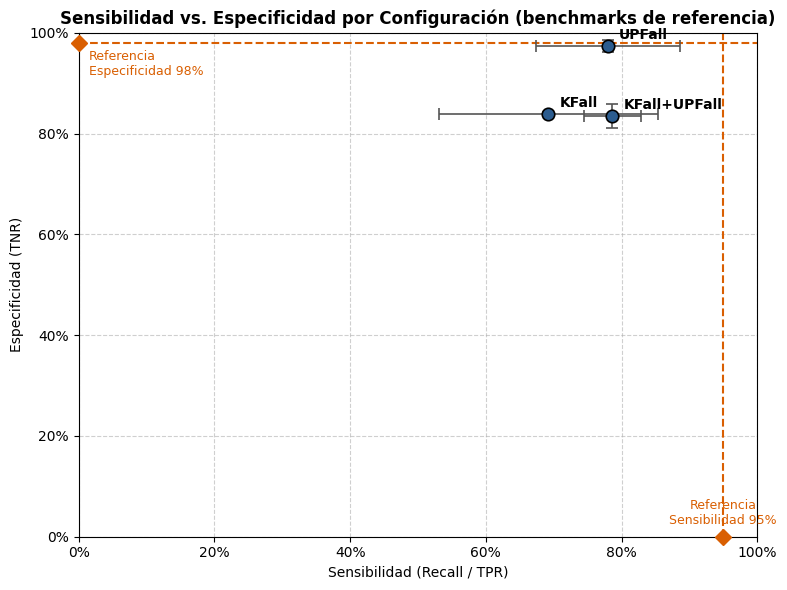

In [17]:
from matplotlib.ticker import PercentFormatter

REF_SENS = 0.95   # sensibilidad de referencia (benchmark de literatura)
REF_SPEC = 0.98   # especificidad de referencia (benchmark de literatura)

def plot_sensitivity_specificity_quadrant(results_df):
    """Sensibilidad vs Especificidad con barras de error ± SD entre folds
    y líneas de referencia marcadas sobre los ejes."""
    sens_mean = results_df["sensitivity_mean"].values
    sens_std = results_df["sensitivity_std"].values
    spec_mean = results_df["specificity_mean"].values
    spec_std = results_df["specificity_std"].values
    names = results_df["config"].values

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Líneas de referencia
    ax.axvline(REF_SENS, color="#d95f02", linestyle="--", linewidth=1.5, zorder=2)
    ax.axhline(REF_SPEC, color="#d95f02", linestyle="--", linewidth=1.5, zorder=2)

    # Marcas de referencia sobre los ejes
    ax.plot(REF_SENS, 0, marker="D", color="#d95f02", markersize=8, clip_on=False, zorder=4)
    ax.plot(0, REF_SPEC, marker="D", color="#d95f02", markersize=8, clip_on=False, zorder=4)
    ax.text(REF_SENS, 0.02, "Referencia\nSensibilidad 95%", ha="center", va="bottom",
            fontsize=9, color="#d95f02", zorder=4)
    ax.text(0.015, 0.965, "Referencia\nEspecificidad 98%", ha="left", va="top",
            fontsize=9, color="#d95f02", zorder=4)

    # Puntos y barras de error (± SD entre folds)
    ax.errorbar(
        sens_mean, spec_mean,
        xerr=sens_std, yerr=spec_std,
        fmt="o", ms=9, mfc="#2b5c8f", mec="black", mew=1.2,
        ecolor="#555555", elinewidth=1.2, capsize=4, ls="none", zorder=3,
    )

    # Etiquetas de configuración sobre el gráfico (sin leyenda separada)
    for x, y, name in zip(sens_mean, spec_mean, names):
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(8, 5),
                    fontsize=10, fontweight="bold", zorder=4)

    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("Sensibilidad (Recall / TPR)")
    ax.set_ylabel("Especificidad (TNR)")
    ax.set_title("Sensibilidad vs. Especificidad por Configuración (benchmarks de referencia)", fontsize=12, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.6, zorder=1)
    plt.tight_layout()
    return fig

results_df = pd.DataFrame(all_results)
fig5 = plot_sensitivity_specificity_quadrant(results_df)
plt.show()


**Sobre las líneas de referencia (95% y 98%)**

Las líneas de referencia provienen de la investigación bibliográfica realizada en el proyecto. La literatura analizada **no establece un estándar regulatorio universal único** para los sistemas de detección de caídas:

- Una **sensibilidad > 95%** aparece como referencia de viabilidad/deseabilidad para la detección de caídas.
- Una **especificidad > 98%** aparece como objetivo de diseño particularmente relevante en monitorización continua, debido al problema de las falsas alarmas.

Estas referencias deben interpretarse como **benchmarks de viabilidad y objetivos de rendimiento reportados en la literatura**, no como criterios regulatorios universales.

**Limitaciones de interpretación**

1. El gráfico permite comparar las configuraciones evaluadas de forma visual.
2. Alcanzar una referencia en el gráfico **no demuestra por sí solo** que el sistema sea apto para despliegue real.
3. Los resultados obtenidos con datasets de laboratorio pueden **no transferirse directamente** al mundo real.
4. La posición de cada punto debe interpretarse junto con su **variabilidad entre folds** (barras de error), especialmente cuando la desviación estándar es elevada.

Esto evita conclusiones exageradas sobre configuraciones con alta variabilidad entre folds.